In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

In [6]:
df = pd.read_csv(r"C:\Users\ARPIT DIMRI\OneDrive\Desktop\Premiere-League-pred-model\data\features.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

model = joblib.load(r"C:\Users\ARPIT DIMRI\OneDrive\Desktop\Premiere-League-pred-model\models\rf_model.pkl")

In [7]:
lr_model = joblib.load("C:\\Users\\ARPIT DIMRI\\OneDrive\\Desktop\\Premiere-League-pred-model\\models\\lr_model.pkl")
rf_model = joblib.load("C:\\Users\\ARPIT DIMRI\\OneDrive\\Desktop\\Premiere-League-pred-model\\models\\rf_model.pkl")


In [11]:
from sklearn.preprocessing import LabelEncoder
le_home = LabelEncoder()
le_away = LabelEncoder()
le_result = LabelEncoder()

df['home_encoded'] = le_home.fit_transform(df['Home'])
df['away_encoded'] = le_home.fit_transform(df['Away'])
df['result_encoded'] = le_home.fit_transform(df['result'])

features = [
    'home_encoded',
    'away_encoded',
    'home_goals_avg',
    'away_goals_avg',
    'home_conceded_avg',
    'away_conceded_avg',
    'home_goal_diff',
    'away_goal_diff',
    'strength_diff',
    'attack_diff',
    'defense_diff'
]

X = df[features]
y = df['result_encoded']



In [12]:
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [15]:
class_names = ['Away Win','Draw','Home Win']

lr_preds = lr_model.predict(X_test)

print("Logistic Regression Accuracy:" ,accuracy_score(y_test,lr_preds))
print(classification_report(y_test,lr_preds,target_names=class_names))

Logistic Regression Accuracy: 0.4928870292887029
              precision    recall  f1-score   support

    Away Win       0.48      0.37      0.42       776
        Draw       0.00      0.00      0.00       542
    Home Win       0.50      0.83      0.62      1072

    accuracy                           0.49      2390
   macro avg       0.33      0.40      0.35      2390
weighted avg       0.38      0.49      0.41      2390



c:\Users\ARPIT DIMRI\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ARPIT DIMRI\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ARPIT DIMRI\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [16]:
rf_preds = rf_model.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,rf_preds))
print(classification_report(y_test,rf_preds,target_names=class_names))

Random Forest Accuracy: 0.4393305439330544
              precision    recall  f1-score   support

    Away Win       0.44      0.37      0.40       776
        Draw       0.22      0.18      0.20       542
    Home Win       0.51      0.62      0.56      1072

    accuracy                           0.44      2390
   macro avg       0.39      0.39      0.39      2390
weighted avg       0.42      0.44      0.43      2390



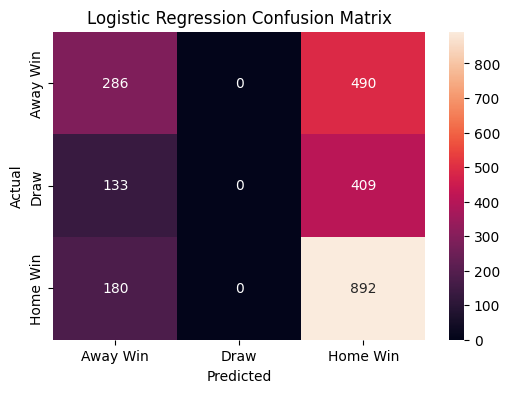

In [17]:
cm_lr = confusion_matrix(y_test,lr_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr,annot=True,fmt = 'd',
            xticklabels = class_names,
            yticklabels= class_names)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
